<a href="https://colab.research.google.com/github/Julian6262/the_founder/blob/main/%D0%94%D0%97-35.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Библиотека линейной алгебры
import numpy as np

# Подготовка данных
import tensorflow as tf

# Построение сети
from keras import Model
from keras.models import Sequential
from keras.layers import Conv2D, Dropout, Dense, Flatten, Conv2DTranspose, BatchNormalization, LeakyReLU, Reshape, ReLU, Input
from keras.callbacks import Callback
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras.metrics import Mean

# MNIST - датасет
from keras.datasets import fashion_mnist

# Работа с графиками
import matplotlib.pyplot as plt
%matplotlib inline

# Отключаем лишние предупреждения
import warnings
warnings.filterwarnings('ignore')

In [ ]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

In [ ]:
# Вывод формы данных
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
x_train = np.concatenate((x_train, x_test), axis=0)

In [ ]:
x_train = (x_train.astype('float32') - 127.5) / 127.5

In [ ]:
x_train = np.expand_dims(x_train, axis=-1)

In [ ]:
print(x_train.shape)

(70000, 28, 28, 1)


In [ ]:
del _, x_test

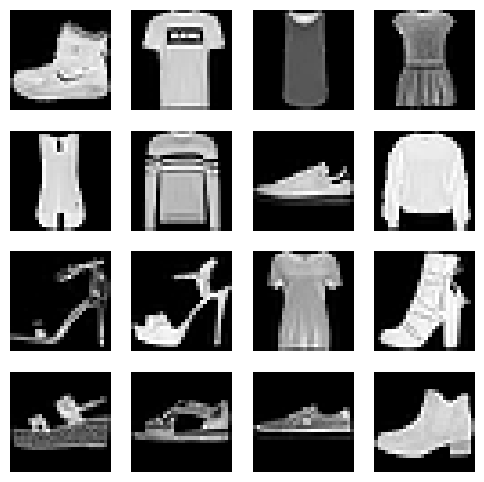

In [ ]:
def plot_images(sqr = 5):
    plt.figure(figsize = (6, 6))
    for i in range(sqr * sqr):
        plt.subplot(sqr, sqr, i+1)
        plt.imshow(x_train[i], cmap='gray')
        plt.axis('off')


plot_images(4)

In [ ]:
SIZE = x_train.shape[1]       # линейный размер изображений (одно измерение)
INPUT_IMG = (SIZE, SIZE, 1)   # размер входного изображений
BATCH_SIZE = 256              # размер пакета для обучения
LATENT_DIM = 100              # размерность латентного пространства

In [ ]:
# dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(1000).batch(BATCH_SIZE).prefetch(1)

In [ ]:
def Generator():
    model = Sequential()

    model.add(Dense(7 * 7 * 256, input_dim=LATENT_DIM))
    model.add(BatchNormalization())
    model.add(ReLU())

    model.add(Reshape((7, 7, 256)))

    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2),padding="same", kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(ReLU())

    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2),padding="same", kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(ReLU())

    model.add(Conv2D(1, (5, 5), padding="same", activation="tanh"))

    return model

In [ ]:
generator = Generator()
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12544)               │       1,266,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12544)               │          50,176 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 14, 14, 128)         │         819,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 28, 28, 64)          │         204,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 1)           │           1,601 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,343,681 (8.94 MB)

 Trainable params: 2,318,209 (8.84 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [ ]:
def Discriminator():
    model = Sequential()
    model.add(Input(INPUT_IMG))

    model.add(Conv2D(64, (5, 5), strides=(2, 2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))

    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))

    model.add(Flatten())
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    return model

In [ ]:
discriminator = Discriminator()
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 128)           │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           6,273 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 213,633 (834.50 KB)

 Trainable params: 213,249 (833.00 KB)

 Non-trainable params: 384 (1.50 KB)

Построим изображение, сгенерированное генератором из шума.

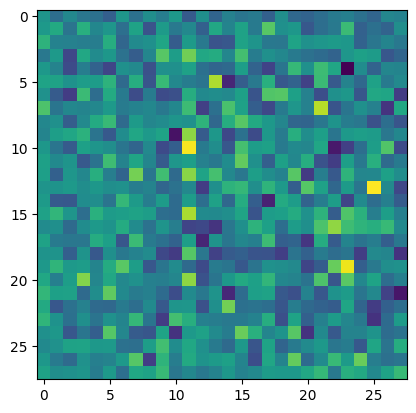

In [ ]:
noise = np.random.normal(0, 1, (1, LATENT_DIM))
img = generator(noise)
plt.imshow(img[0,:,:,0])
plt.show()

In [ ]:
# class DCGAN(Model):
#     def __init__(self, discriminator, generator, latent_dim):
#         super().__init__()
#         self.discriminator = discriminator
#         self.generator = generator
#         self.latent_dim = latent_dim
#         self.d_loss_metric = Mean(name="d_loss")
#         self.g_loss_metric = Mean(name="g_loss")

#     def compile(self, d_optimizer, g_optimizer, loss_fn):
#         super(DCGAN, self).compile()
#         self.d_optimizer = d_optimizer
#         self.g_optimizer = g_optimizer
#         # self.loss_fn = loss_fn

#     # @property
#     # def metrics(self):
#     #     return [self.d_loss_metric, self.g_loss_metric]

#     @tf.function
#     def train_step(self, images):
#         # генерируем шум на входе генератора
#         noise = np.random.normal(0, 1, (BATCH_SIZE, self.latent_dim))

#         # Инициализируем GradientTape (градиентную ленту) для дискриминатора и генератор
#         #  по отдельности, чтобы записать операции,
#         # выполняемые во время прямого прохода, включающего автодифференцирование.
#         with tf.GradientTape() as gen_tape , tf.GradientTape() as disc_tape:
#             # Запустим прямой проход шума через генератор.
#             # Операции применяемые каждым слоем к своим
#             # входным данным будут записаны на GradientTape, как на ленту магнитофона.
#             # Отсюда и название градиентной ленты.
#             generated_images = generator(noise)

#             # Также обеспечиваем прямой проход через дискриминатор для
#             # для реальных и фейковых изображений
#             fake_output = discriminator(generated_images)
#             real_output = discriminator(images)

#             # расчитываем функции ошибок (значения потерь)
#             gen_loss = generator_loss(fake_output)
#             dis_loss = discriminator_loss(fake_output, real_output)

#         # Используем gradient tape для автоматического извлечения градиентов
#         # обучаемых переменных относительно потерь.
#         gradient_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
#         gradient_of_discriminator = disc_tape.gradient(dis_loss, discriminator.trainable_variables)

#         # Выполним один шаг градиентного спуска, обновив
#         # значение переменных минимизирующих потери.
#         self.g_optimizer.apply_gradients(zip(gradient_of_generator,generator.trainable_variables))
#         self.d_optimizer.apply_gradients(zip(gradient_of_discriminator, discriminator.trainable_variables))

#         # self.d_loss_metric.update_state(dis_loss)
#         # self.g_loss_metric.update_state(gen_loss)

#         # Вернем значения потерь для визуализации
#         loss = {'gen_loss':gen_loss, 'disc_loss': dis_loss}

#         return loss

#         # return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

In [ ]:
class DCGAN(Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_loss_metric = Mean(name="d_loss")
        self.g_loss_metric = Mean(name="g_loss")

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))

        # Шаг 1. Обучение дискриминатора работать как с реальными изображениями, так и с поддельными изображениями.
        with tf.GradientTape() as tape:
            # Вычисление потерь дискриминатора на реальных изображениях
            pred_real = self.discriminator(real_images, training=True)
            d_loss_real = self.loss_fn(tf.ones((batch_size, 1)), pred_real)

            # Вычисление потерь дискриминатора на поддельных изображениях
            fake_images = self.generator(noise)
            pred_fake = self.discriminator(fake_images, training=True)
            d_loss_fake = self.loss_fn(tf.zeros((batch_size, 1)), pred_fake)

            # общие потери дискриминатора
            d_loss = (d_loss_real + d_loss_fake)/2
        # Вычисление градиентов дискриминатора
        grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        # Обновление весов дискриминатора
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

        # Шаг 2. Обучение генератора.
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            fake_images = self.generator(noise, training=True)
            pred_fake = self.discriminator(fake_images, training=True)
            g_loss = self.loss_fn(misleading_labels, pred_fake)
        # Вычисление градиентов генератора
        grads = tape.gradient(g_loss, self.generator.trainable_variables)
        # Обновление весов генератора
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_variables))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

In [ ]:
class GANMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=100):
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.seed = np.random.normal(0, 1, (self.num_img * self.num_img, latent_dim))

    def on_epoch_end(self, epoch, logs=None):
        img = self.model.generator(self.seed)

        plt.figure(figsize = (6, 6))
        for i in range(self.num_img * self.num_img):
          plt.subplot(self.num_img, self.num_img, i + 1)
          plt.imshow((img[i,:,:,0] * 127.5) + 127.5, cmap='gray')

          plt.axis('off')
          plt.grid()

        plt.show()

In [ ]:
dcgan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM)

In [ ]:
LR = 0.0002

dcgan.compile(
    d_optimizer=Adam(learning_rate=LR, beta_1 = 0.5),
    g_optimizer=Adam(learning_rate=LR, beta_1 = 0.5),
    loss_fn=BinaryCrossentropy(),
)

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - d_loss: 0.1427 - g_loss: 0.8070

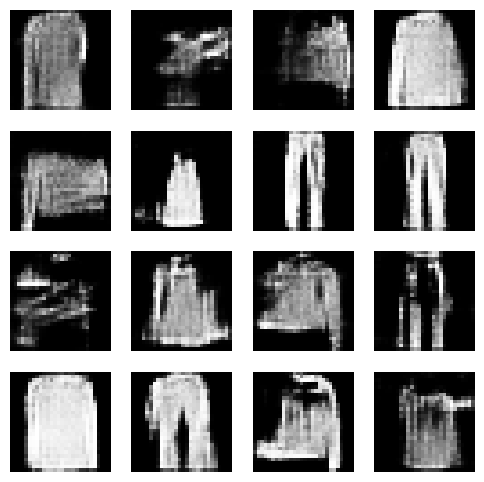

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - d_loss: 0.1428 - g_loss: 0.8072
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.5923 - g_loss: 1.2064

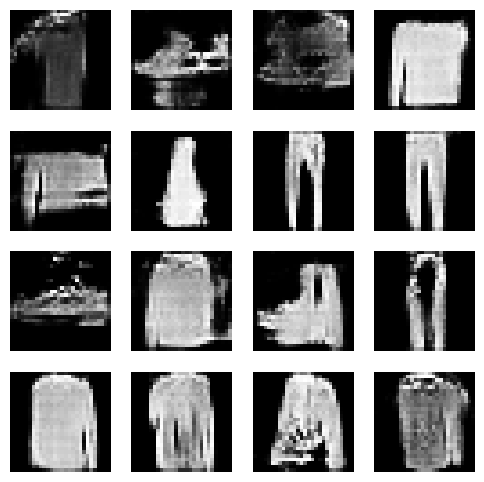

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.5923 - g_loss: 1.2063
Epoch 3/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - d_loss: 0.6334 - g_loss: 1.0338

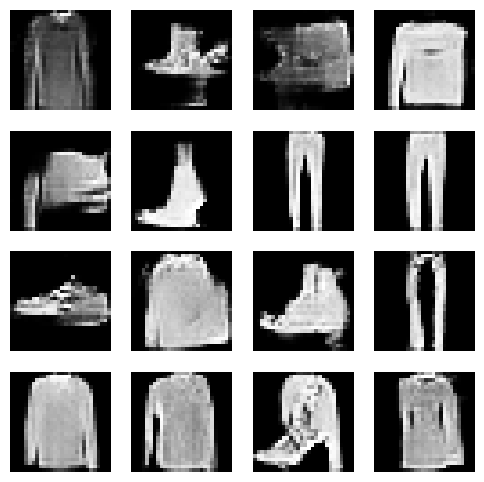

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 45s 17ms/step - d_loss: 0.6334 - g_loss: 1.0337
Epoch 4/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - d_loss: 0.6398 - g_loss: 0.9730

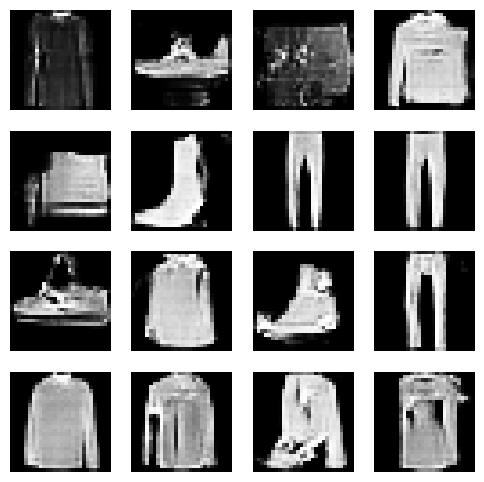

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - d_loss: 0.6398 - g_loss: 0.9729
Epoch 5/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6450 - g_loss: 0.9314

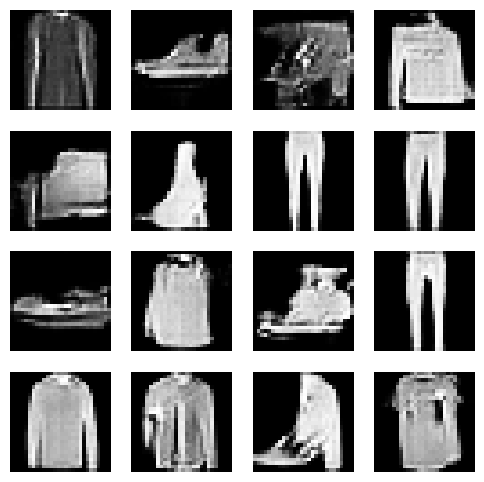

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - d_loss: 0.6450 - g_loss: 0.9314
Epoch 6/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - d_loss: 0.6488 - g_loss: 0.9139

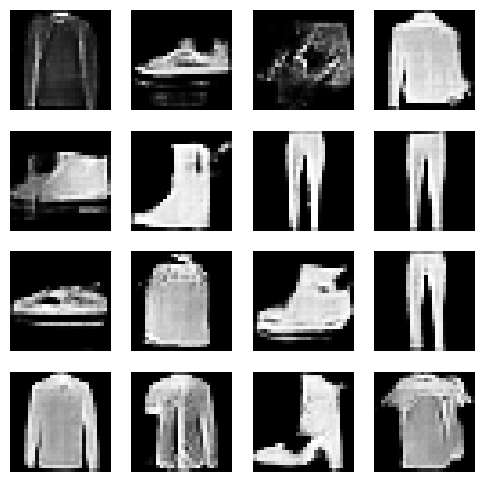

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - d_loss: 0.6488 - g_loss: 0.9139
Epoch 7/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6512 - g_loss: 0.9078

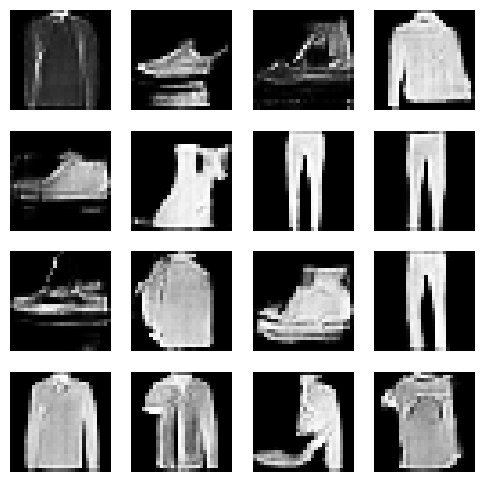

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - d_loss: 0.6512 - g_loss: 0.9078
Epoch 8/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6522 - g_loss: 0.8924

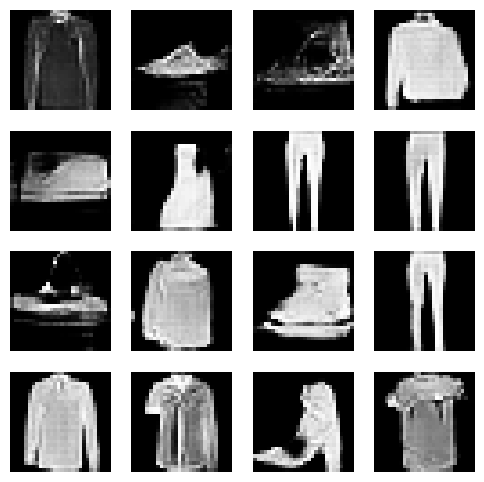

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6522 - g_loss: 0.8924
Epoch 9/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - d_loss: 0.6531 - g_loss: 0.8906

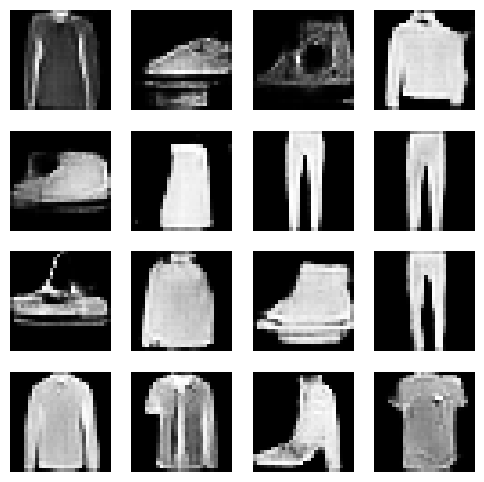

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 45s 18ms/step - d_loss: 0.6531 - g_loss: 0.8906
Epoch 10/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - d_loss: 0.6551 - g_loss: 0.8907

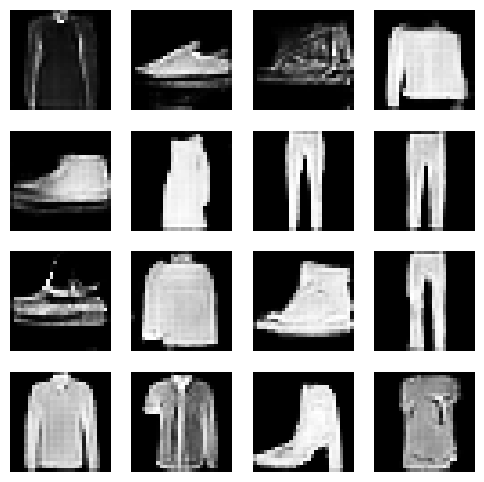

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - d_loss: 0.6551 - g_loss: 0.8906
Epoch 11/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6567 - g_loss: 0.8782

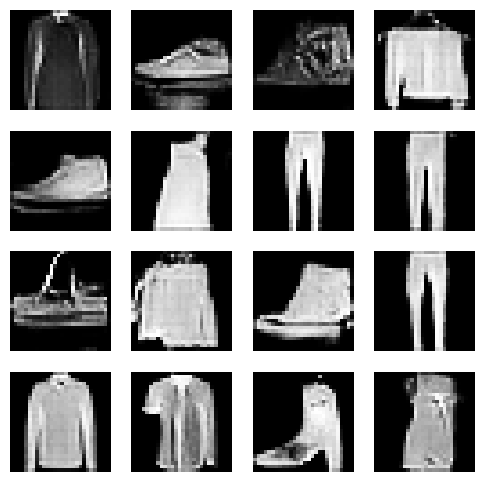

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6567 - g_loss: 0.8782
Epoch 12/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6592 - g_loss: 0.8676

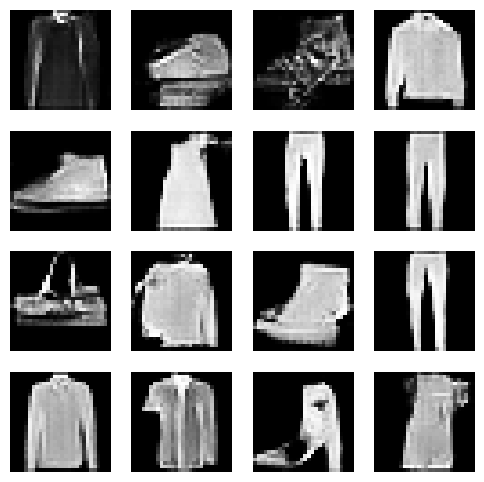

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6592 - g_loss: 0.8676
Epoch 13/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6581 - g_loss: 0.8607

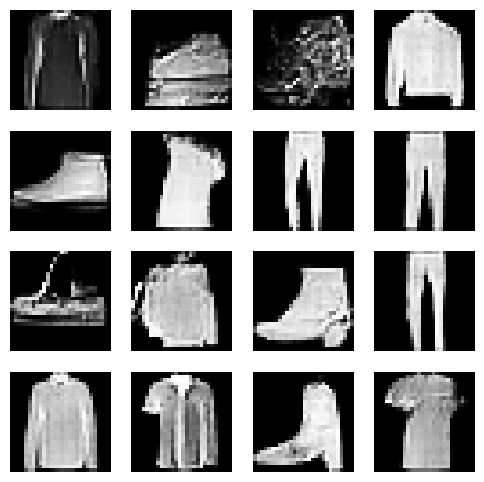

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6581 - g_loss: 0.8607
Epoch 14/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6579 - g_loss: 0.8618

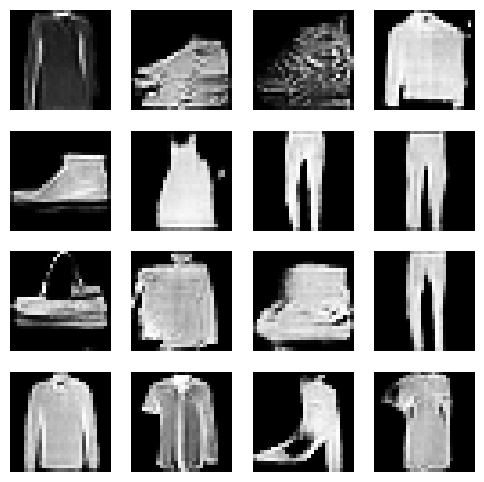

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6579 - g_loss: 0.8618
Epoch 15/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6583 - g_loss: 0.8586

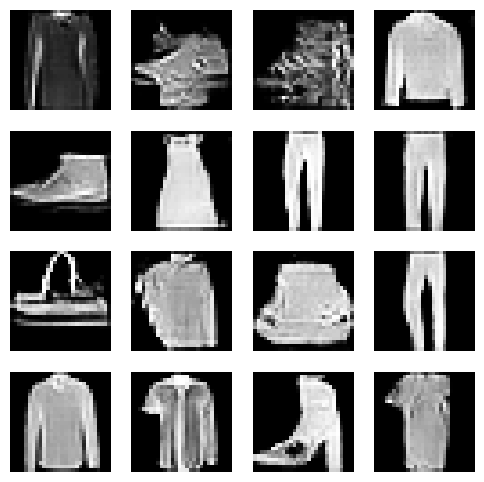

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6583 - g_loss: 0.8586
Epoch 16/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6585 - g_loss: 0.8625

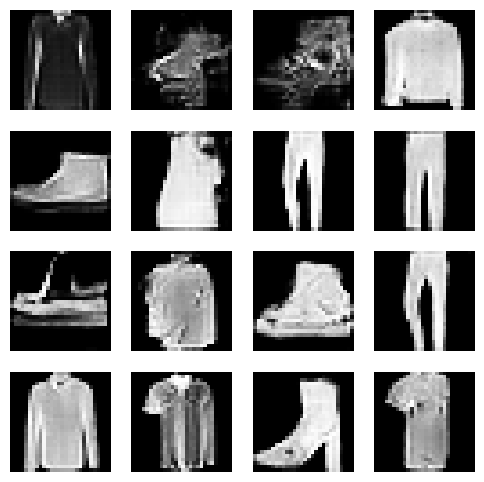

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6585 - g_loss: 0.8625
Epoch 17/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6585 - g_loss: 0.8591

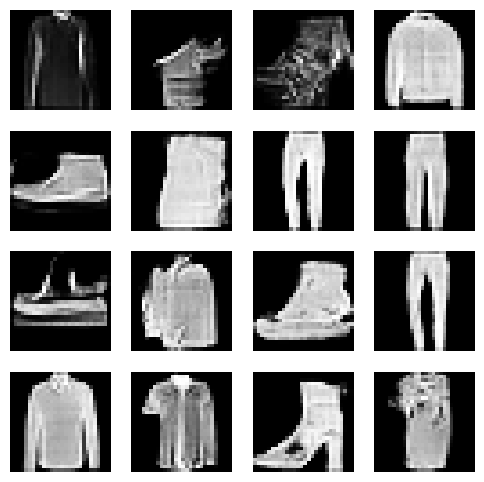

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6585 - g_loss: 0.8591
Epoch 18/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6589 - g_loss: 0.8520

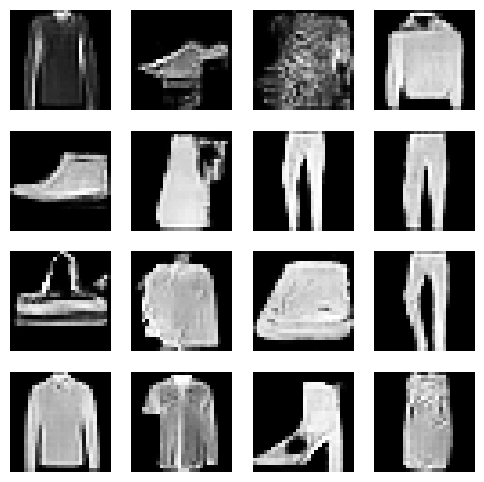

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6589 - g_loss: 0.8520
Epoch 19/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6574 - g_loss: 0.8502

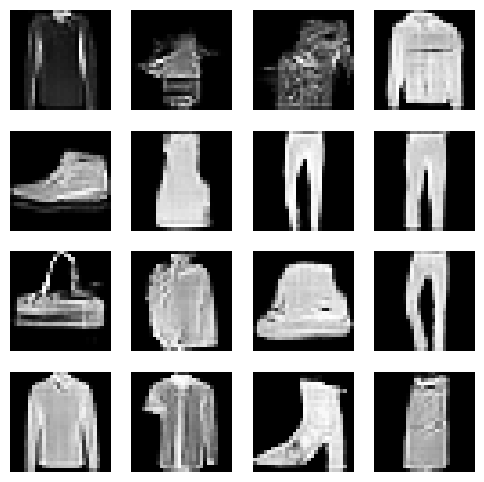

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6574 - g_loss: 0.8502
Epoch 20/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6616 - g_loss: 0.8484

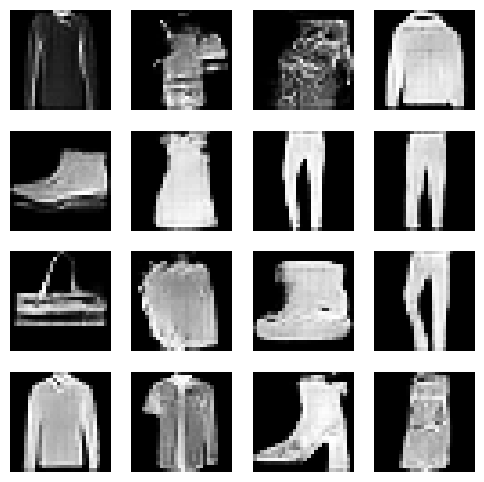

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6616 - g_loss: 0.8484
Epoch 21/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6592 - g_loss: 0.8492

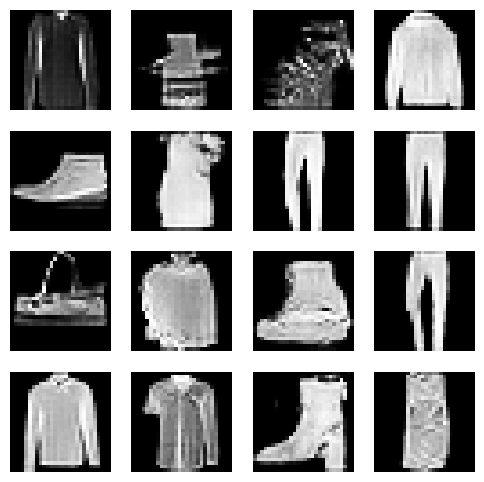

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6592 - g_loss: 0.8492
Epoch 22/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6600 - g_loss: 0.8469

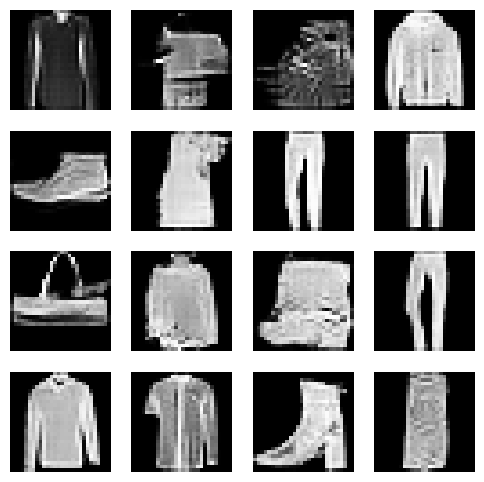

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6600 - g_loss: 0.8469
Epoch 23/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6569 - g_loss: 0.8539

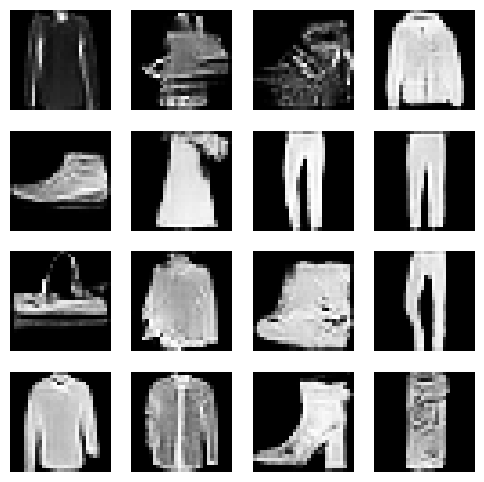

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6569 - g_loss: 0.8539
Epoch 24/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6586 - g_loss: 0.8512

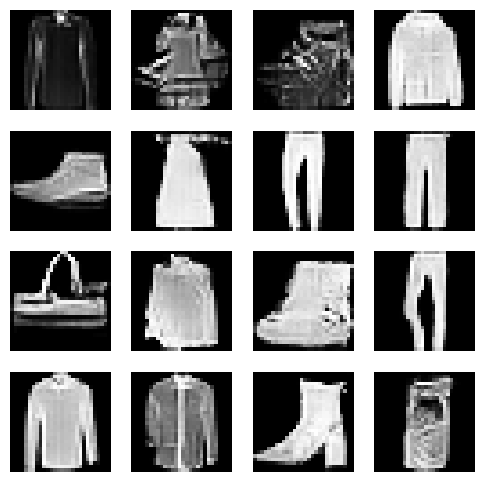

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6586 - g_loss: 0.8512
Epoch 25/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6585 - g_loss: 0.8516

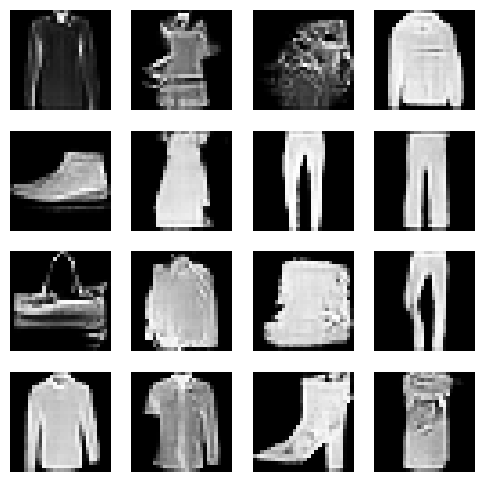

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6585 - g_loss: 0.8516
Epoch 26/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6566 - g_loss: 0.8495

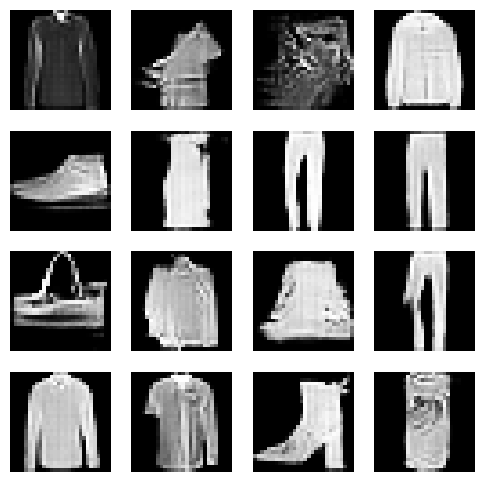

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6566 - g_loss: 0.8495
Epoch 27/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6596 - g_loss: 0.8494

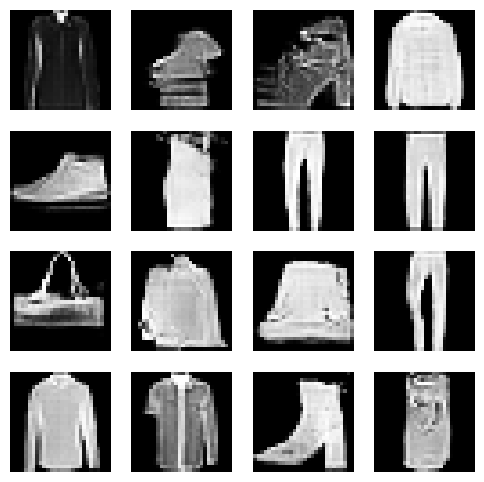

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6596 - g_loss: 0.8494
Epoch 28/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6571 - g_loss: 0.8491

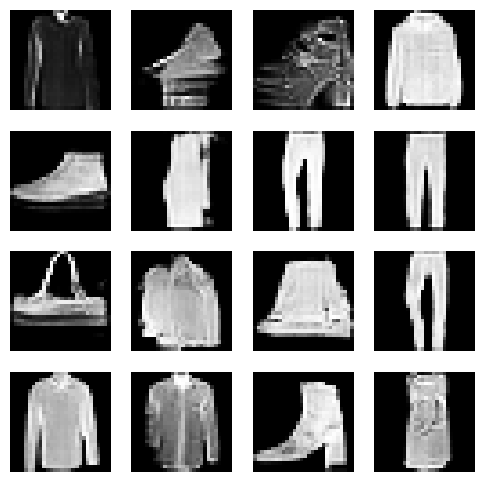

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6571 - g_loss: 0.8491
Epoch 29/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6582 - g_loss: 0.8449

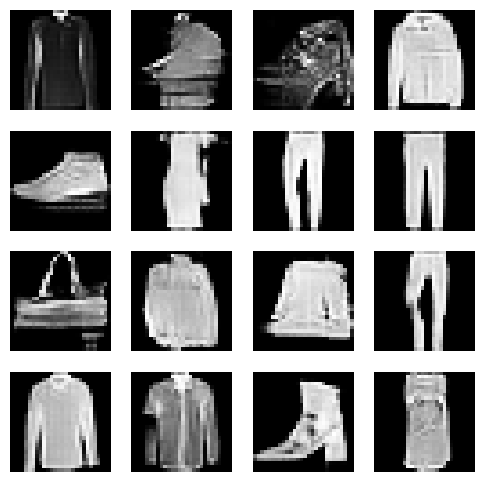

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6582 - g_loss: 0.8449
Epoch 30/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6563 - g_loss: 0.8496

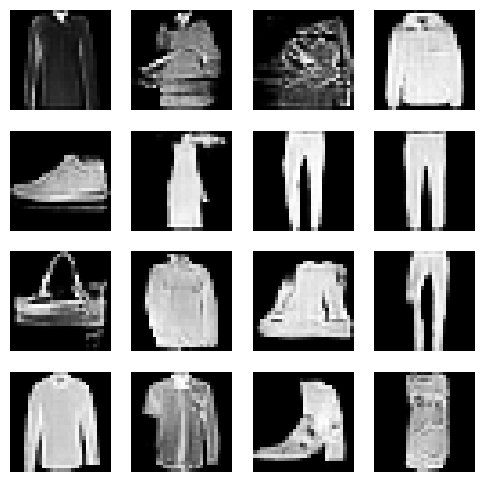

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6563 - g_loss: 0.8496
Epoch 31/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6567 - g_loss: 0.8486

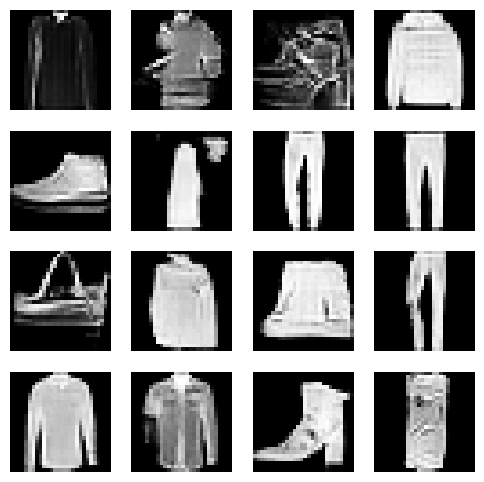

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6567 - g_loss: 0.8486
Epoch 32/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6586 - g_loss: 0.8459

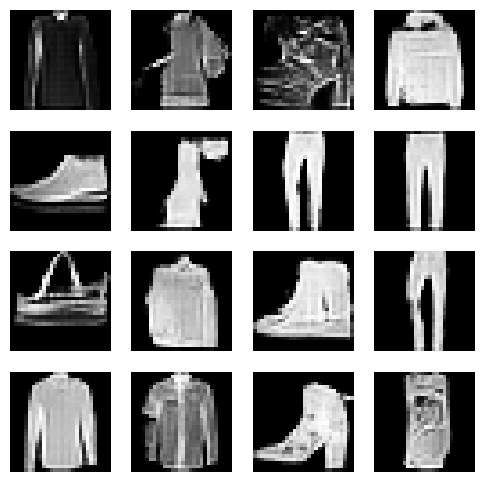

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6586 - g_loss: 0.8459
Epoch 33/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6599 - g_loss: 0.8497

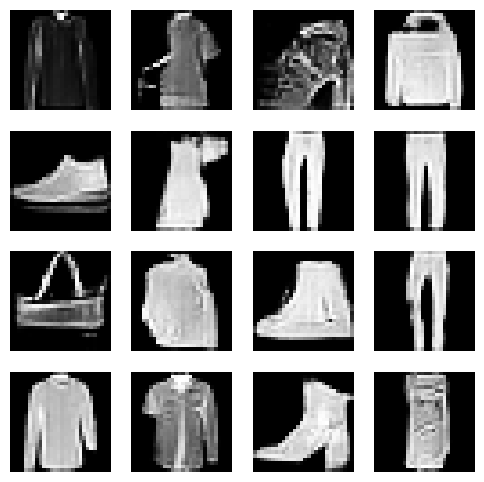

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6599 - g_loss: 0.8497
Epoch 34/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6610 - g_loss: 0.8428

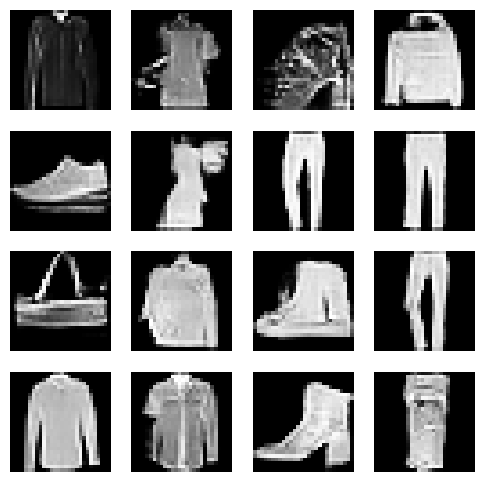

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6610 - g_loss: 0.8428
Epoch 35/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6601 - g_loss: 0.8406

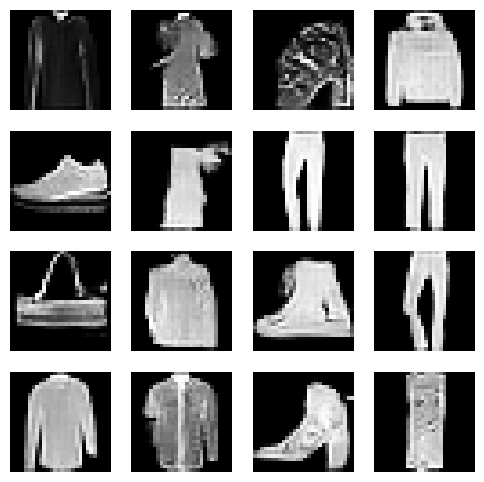

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6601 - g_loss: 0.8406
Epoch 36/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6576 - g_loss: 0.8437

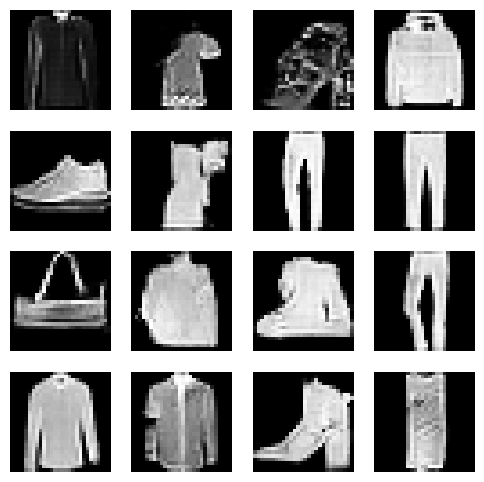

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6576 - g_loss: 0.8437
Epoch 37/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6571 - g_loss: 0.8446

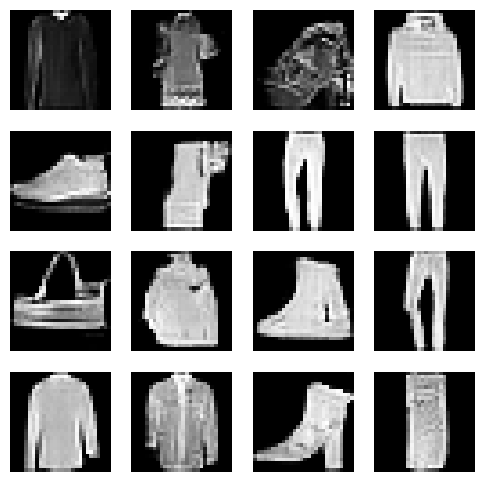

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6571 - g_loss: 0.8446
Epoch 38/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6586 - g_loss: 0.8476

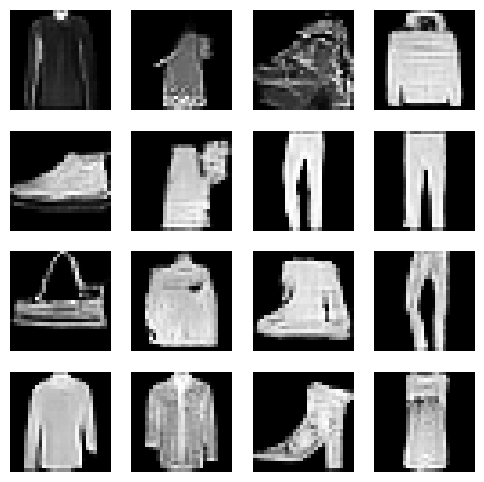

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6586 - g_loss: 0.8476
Epoch 39/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6561 - g_loss: 0.8487

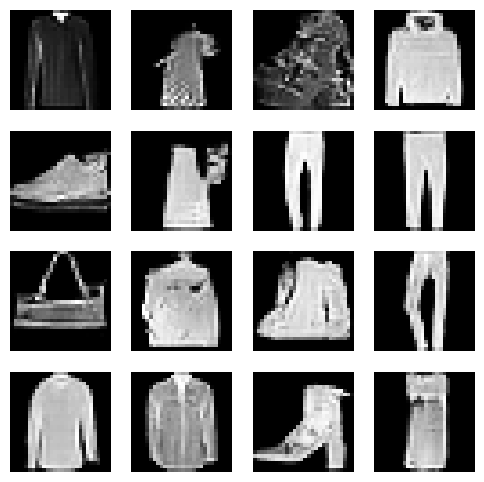

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - d_loss: 0.6561 - g_loss: 0.8487
Epoch 40/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6574 - g_loss: 0.8477

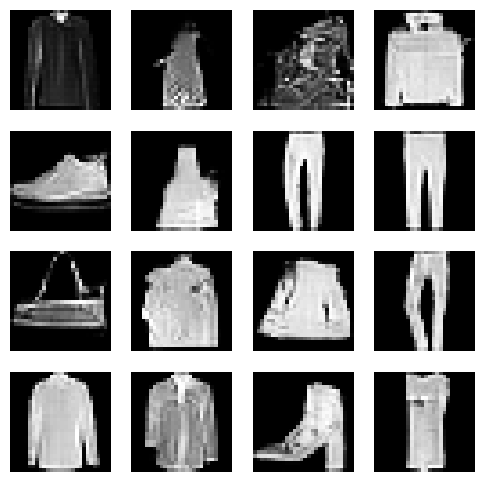

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6574 - g_loss: 0.8476
Epoch 41/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6577 - g_loss: 0.8483

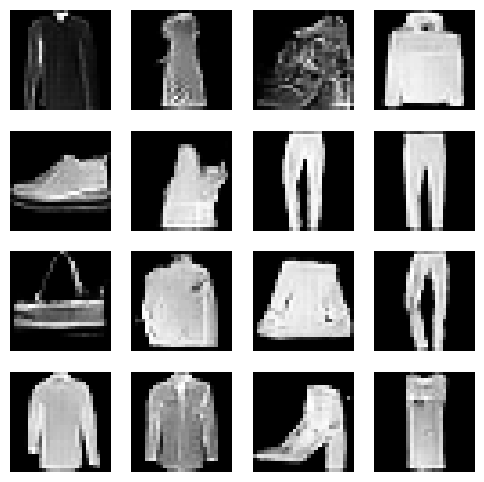

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6577 - g_loss: 0.8483
Epoch 42/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6559 - g_loss: 0.8511

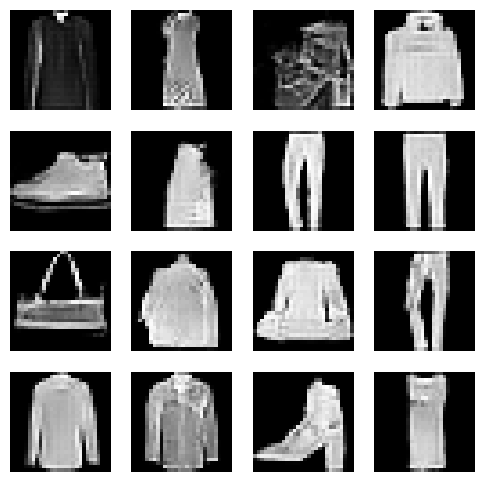

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6559 - g_loss: 0.8511
Epoch 43/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6563 - g_loss: 0.8481

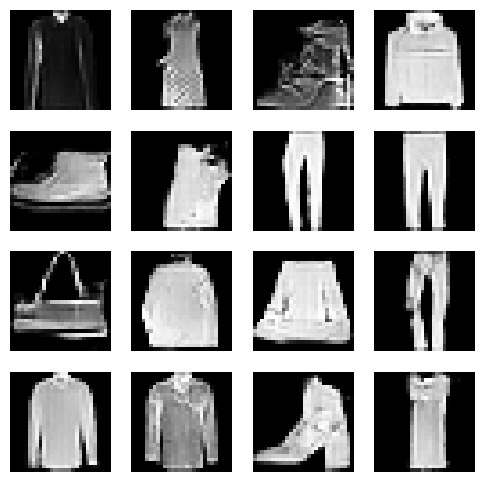

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6563 - g_loss: 0.8481
Epoch 44/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6558 - g_loss: 0.8463

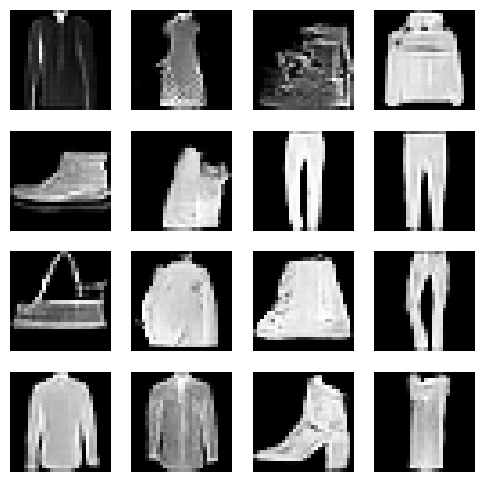

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - d_loss: 0.6558 - g_loss: 0.8463
Epoch 45/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6572 - g_loss: 0.8466

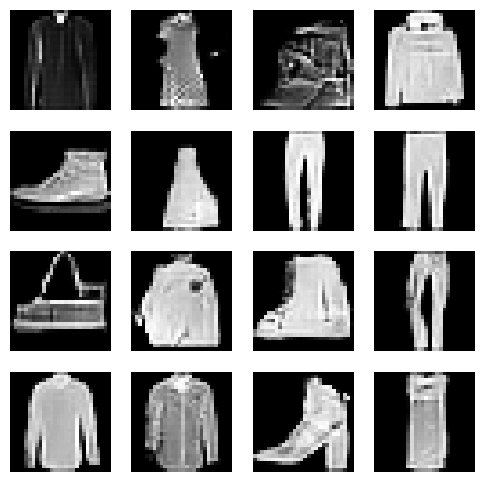

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6572 - g_loss: 0.8466
Epoch 46/50
2185/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6567 - g_loss: 0.8540

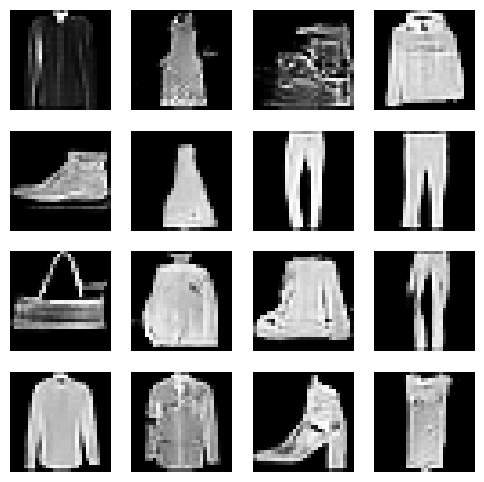

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6567 - g_loss: 0.8540
Epoch 47/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - d_loss: 0.6569 - g_loss: 0.8475

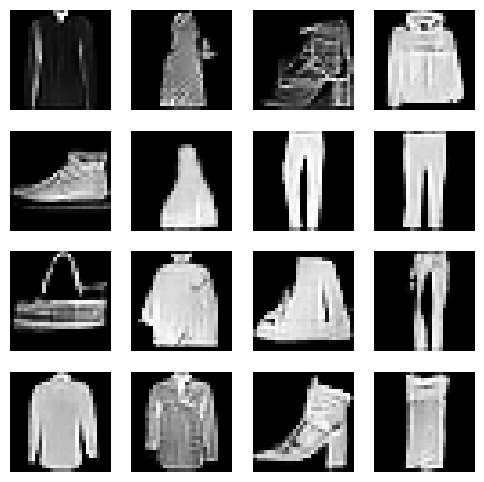

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6569 - g_loss: 0.8475
Epoch 48/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6557 - g_loss: 0.8450

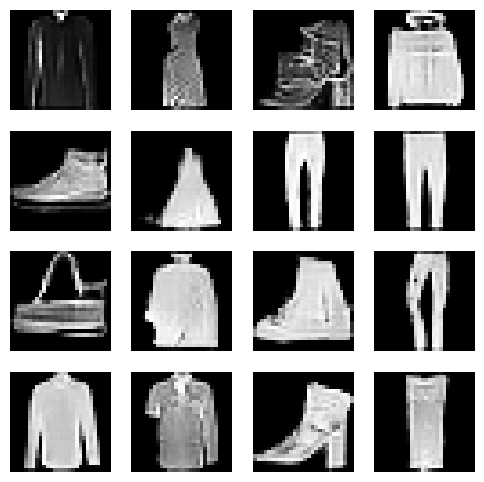

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - d_loss: 0.6557 - g_loss: 0.8450
Epoch 49/50
2186/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6550 - g_loss: 0.8476

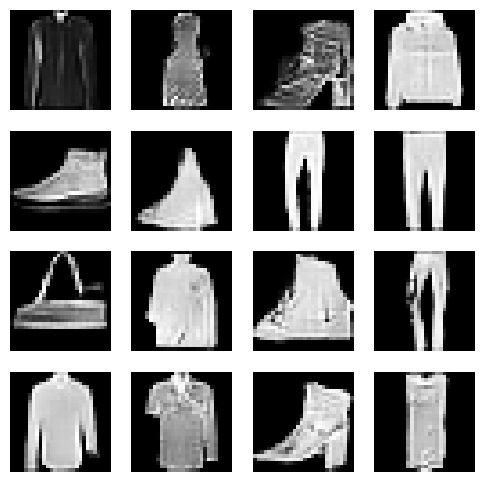

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6550 - g_loss: 0.8476
Epoch 50/50
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6562 - g_loss: 0.8514

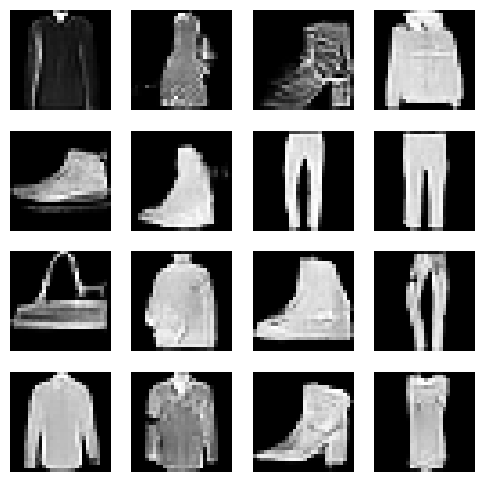

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - d_loss: 0.6562 - g_loss: 0.8514


In [ ]:
NUM_EPOCHS = 50

history = dcgan.fit(x_train, epochs=NUM_EPOCHS, callbacks=[GANMonitor(num_img=4, latent_dim=LATENT_DIM)])

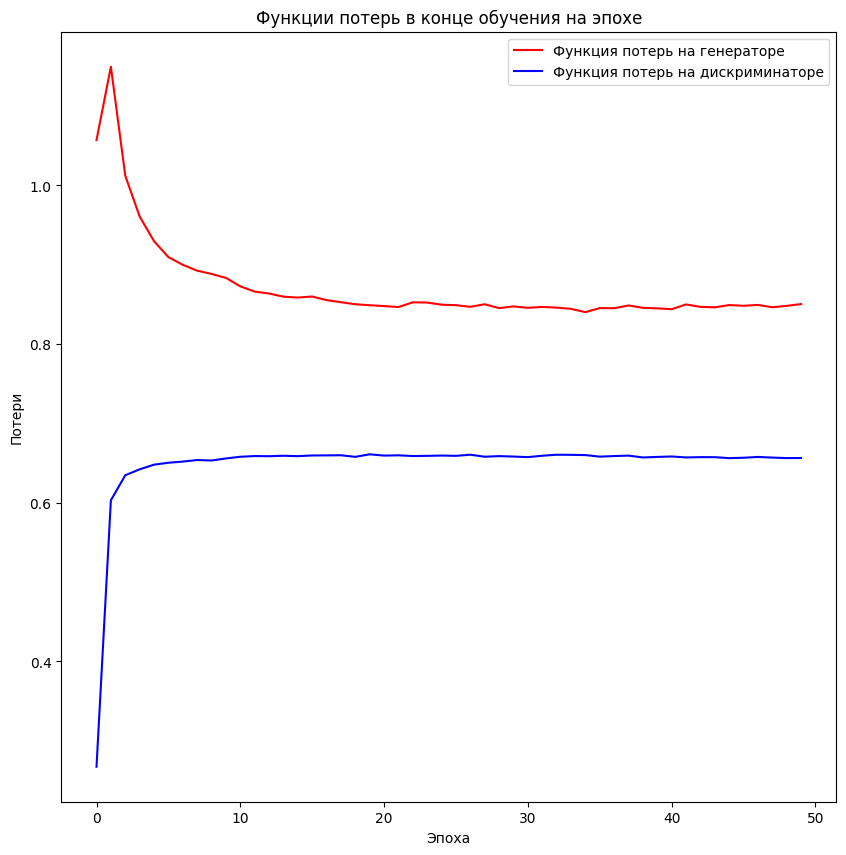

In [ ]:
def loss_plot(G, D):
    plt.figure(figsize=(10,10))
    plt.plot(G, color='red',label='Функция потерь на генераторе')
    plt.plot(D, color='blue',label='Функция потерь на дискриминаторе')
    plt.legend()
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.title('Функции потерь в конце обучения на эпохе')
    plt.show()


history = history.history
loss_plot(history['g_loss'], history['d_loss'])

Посмотрим на генеративные способности генератора уже после 50 эпох

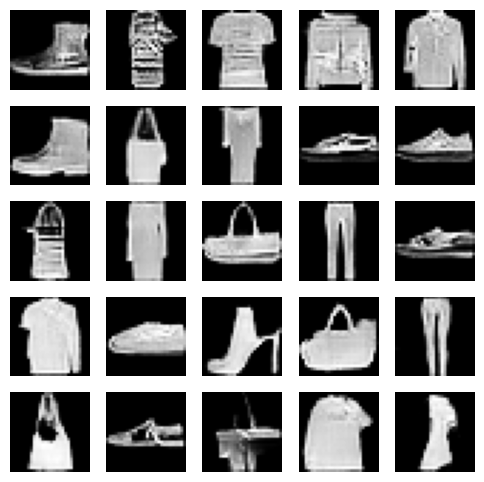

In [ ]:
def plot_generated_images(square = 5):
  plt.figure(figsize = (6,6))
  for i in range(square * square):
    plt.subplot(square, square, i+1)
    noise = np.random.normal(0,1,(1,LATENT_DIM))
    img = generator(noise)
    plt.imshow((img[0,:,:,0] * 127.5) + 127.5, cmap='gray')

    plt.axis('off')
    plt.grid()


plot_generated_images(5)